In [1]:
import pandas as pd
import importlib

c:\Users\manoj\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [6]:
df = pd.read_csv("../data/retail_data.csv")

df.head()

,order_id,user_id,order_date,time,order_hour_of_day,product_name,quantity,price,category,product_id
0,1000,341,2024-09-04,15:43:00,15,Wheat Flour,1,333.44,Grains & Staples,457
1,1000,341,2024-09-04,15:43:00,15,Dishwashing Liquid,2,405.92,Household,745
2,1000,341,2024-09-04,15:43:00,15,Pastry,2,114.15,Bakery,849
3,1000,341,2024-09-04,15:43:00,15,Marker,2,171.33,Stationery,599
4,1001,324,2024-03-07,8:45:00,8,Saree,2,41.16,Clothing,329


In [3]:
from steps.basic_inspection import Basic_inspection
from steps import basic_inspection
import importlib

importlib.reload(basic_inspection)

<module 'steps.basic_inspection' from 'd:\\Documents\\github\\Retail_Shelf_Space_Optimizer\\retail_shelf_space_optimizer\\EDA\\steps\\basic_inspection.py'>

In [7]:
ba = Basic_inspection(df)

ba.shape()

the number of rows: 10000
the number of columns: 10


In [69]:
ba.describe()

data describe


,order_id,user_id,order_hour_of_day,quantity,price,product_id
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1996.630700,248.256900,13.808800,2.009400,255.973973,545.721800
std,572.906224,145.251605,4.928354,0.820597,141.302119,260.980239
min,1000.000000,1.000000,6.000000,1.000000,10.090000,100.000000
25%,1506.000000,119.000000,9.000000,1.000000,132.957500,318.750000
50%,1996.500000,252.000000,14.000000,2.000000,257.195000,548.000000
75%,2492.250000,373.000000,18.000000,3.000000,377.772500,771.000000
max,2990.000000,500.000000,22.000000,3.000000,499.960000,999.000000


In [70]:
ba.info()

data information
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   order_date         10000 non-null  str    
 3   time               10000 non-null  str    
 4   order_hour_of_day  10000 non-null  int64  
 5   product_name       10000 non-null  str    
 6   quantity           10000 non-null  int64  
 7   price              10000 non-null  float64
 8   category           10000 non-null  str    
 9   product_id         10000 non-null  int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 1.1 MB


In [71]:
ba.nullvalues()

identifying the null values


order_id             0
user_id              0
order_date           0
time                 0
order_hour_of_day    0
product_name         0
quantity             0
price                0
category             0
product_id           0
dtype: int64

columns of:
- 'order_date' :converting object data-type to datetime data-type and extracting the month for the order date
- 'time' : data type is incorrect so converted object into standard (hour/minute/seconds)

created a new columns:
- 'month'
- 'hour'

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month']      = df['order_date'].dt.month
df["time"]       = pd.to_datetime(df["time"], format="%H:%M:%S")
df["hour"]       = df['time'].dt.hour

df['order_date']  = pd.to_datetime(df['order_date'])
df['day'] = df['order_date'].dt.day

df["day_name"] = df["order_date"].dt.day_name()
df["day_type"] = df["day_name"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

df.to_csv("retail_data_clenned_dataset.csv", index= False)

In [ ]:
# saving the new updates data-set
# df.to_csv("retail_data_interim.csv",index=False)

***Basic inspection***: The dataset contains 1000 rows and 10 columns. The data types are correctly set expecting col : order_date, time and no missing values were identified.

! there is no missing values in this data set

**Feature Understanding**

In [ ]:
from EDA.steps.feature_understanding import Features
from EDA.steps import feature_understanding

importlib.reload(feature_understanding)

<module 'EDA.feature_understanding' from 'd:\\Documents\\github\\Retail_Shelf_Space_Optimizer\\retail_shelf_space_optimizer\\EDA\\feature_understanding.py'>

In [12]:
fa = Features(df)

In [13]:
fa.nunique("order_date")


column : order_date
Number - of Unique
363


In [120]:
fa.nunique("order_id")


column : order_id
Number - of Unique
1991


In [121]:
fa.nunique("user_id")


column : user_id
Number - of Unique
488


In [135]:
fa.column("order_hour_of_day")


column : order_hour_of_day
Number - of Unique
17
None

column : order_hour_of_day
Value - Counts

order_hour_of_day
7     670
11    655
6     641
16    635
8     635
15    614
21    606
19    579
12    579
18    578
9     571
13    557
14    551
22    537
10    537
20    535
17    520
Name: count, dtype: int64
None


In [136]:
fa.column("product_name")


column : product_name
Number - of Unique
68
None

column : product_name
Value - Counts

product_name
Chips                 167
Energy Drink          166
Dishwashing Liquid    165
Cake                  164
Tissue                164
                     ... 
Fiction Book          129
Orange                128
Marker                125
Shirt                 122
Educational Book      120
Name: count, Length: 68, dtype: int64
None


In [137]:
fa.column("quantity")


column : quantity
Number - of Unique
3
None

column : quantity
Value - Counts

quantity
3    3414
1    3320
2    3266
Name: count, dtype: int64
None


In [139]:
fa.column("category")


column : category
Number - of Unique
17
None

column : category
Value - Counts

category
Grains & Staples        1180
Fruits & Vegetables     1159
Bakery                   769
Household                764
Beverages                746
Dairy & Eggs             738
Electronics              727
Snacks                   607
Meat & Seafood           604
Personal Care            585
Clothing                 557
Stationery               419
Baby Care                301
Health & Wellness        280
Books                    249
Footwear                 162
Clothing Accessories     153
Name: count, dtype: int64
None


In [140]:
fa.column("product_id")


column : product_id
Number - of Unique
900
None

column : product_id
Value - Counts

product_id
723    23
629    22
286    22
899    21
992    21
       ..
964     3
534     3
638     3
907     3
936     2
Name: count, Length: 900, dtype: int64
None


***Feature Understanding***

- Total number of users: 488
- The dataset contains transaction data for 363 days
- There are 17 product categories, and the most ordered categories are Grains & Staples and Fruits & Vegetables
- The highest ordered quantity is 3
- There are 68 products in total, and the top 2 products are from the Bakery category

**Univariate Analysis**

In [ ]:
from steps.univariate_analysis import Univariate_Analysis
from steps import univariate_analysis

importlib.reload(univariate_analysis)

In [119]:
df = pd.read_csv("data/retail_data_interim.csv")

In [ ]:
#df = df.drop('Unnamed: 0',axis=1)

In [213]:
ua = Univariate_Analysis(df)

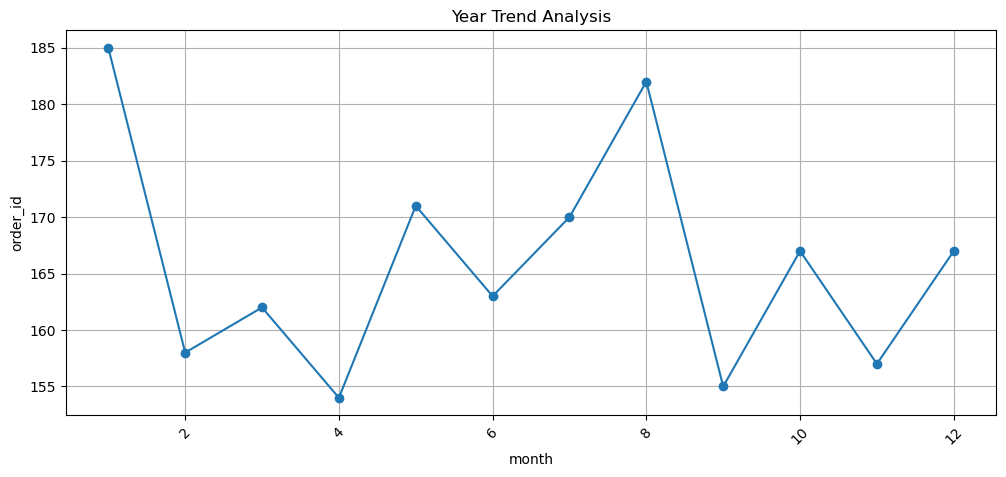

In [ ]:
# identifying the year trend

ua.line_with_unique("month","order_id","Year Trend Analysis")

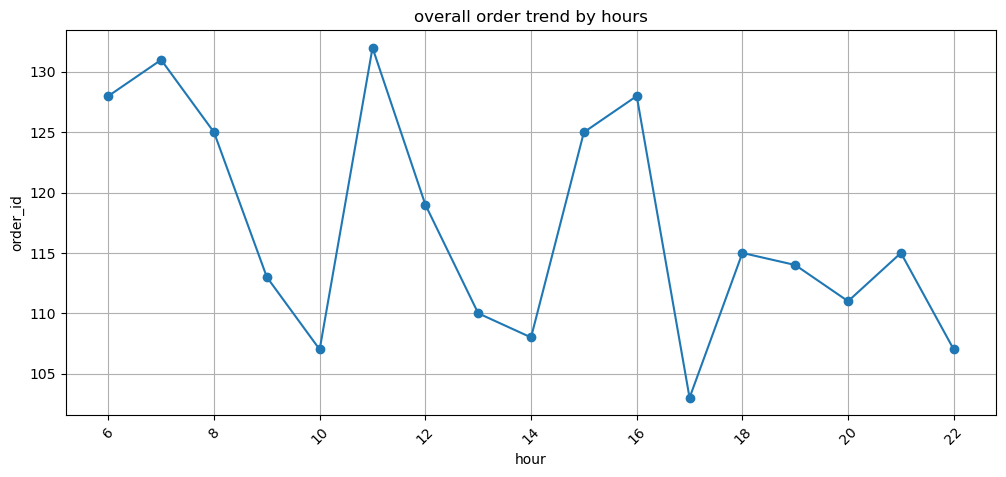

In [82]:
# identiying the peak order hour of the day?

ua.line_with_unique("hour","order_id","overall order trend by hours")

d:\Documents\github\Retail_Shelf_Space_Optimizer\retail_shelf_space_optimizer\EDA\univariate_analysis.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
d:\Documents\github\Retail_Shelf_Space_Optimizer\retail_shelf_space_optimizer\EDA\univariate_analysis.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


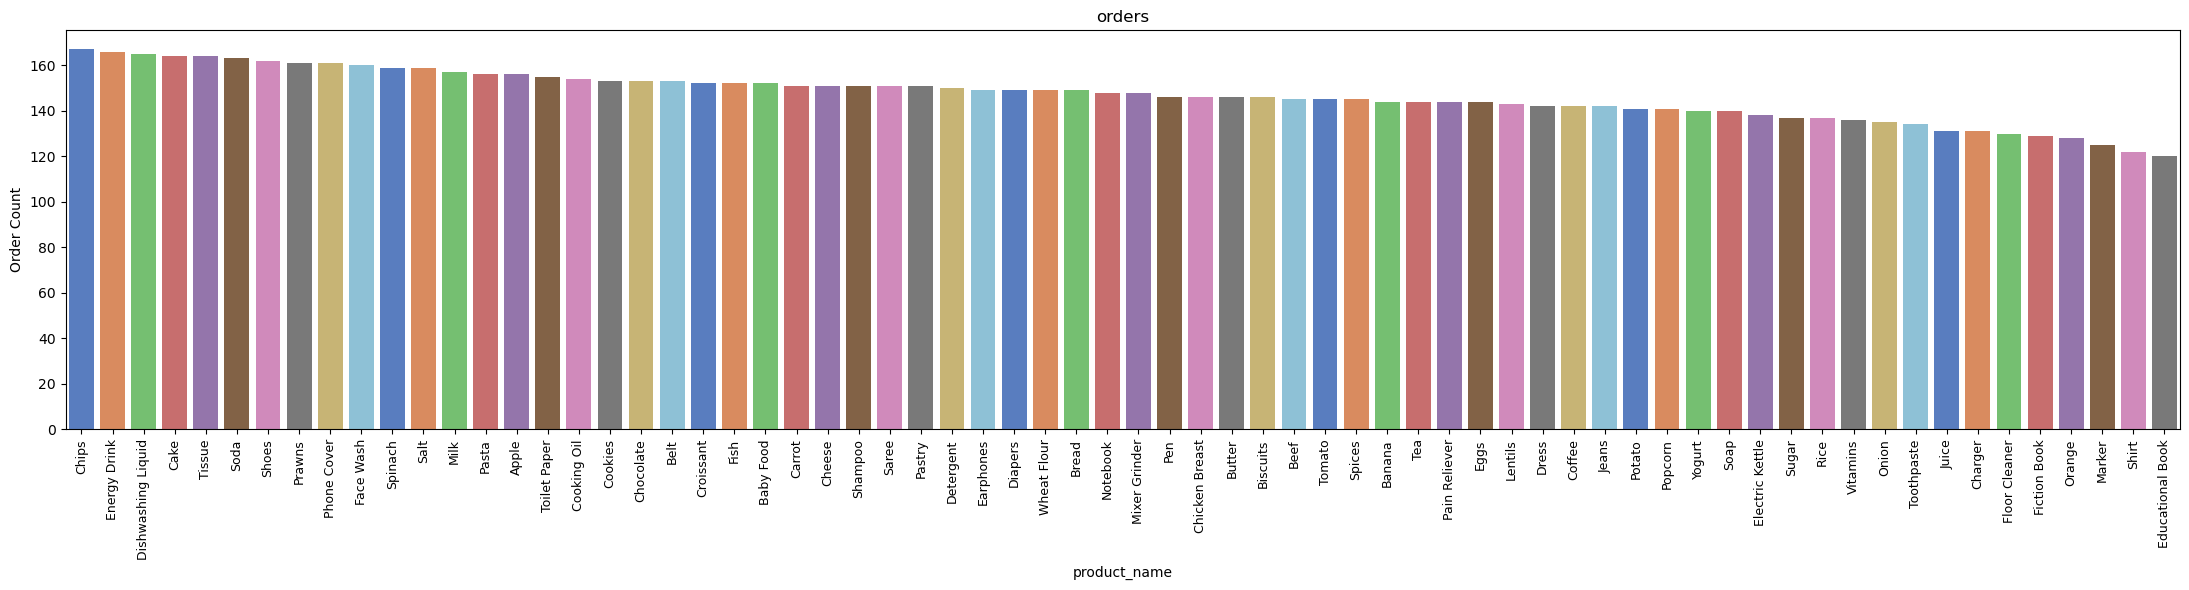

,product_id
count,68.000000
mean,147.058824
std,10.933834
min,120.000000
25%,141.000000
50%,148.000000
75%,153.250000
max,167.000000


In [215]:
# what is the top most ordered pro

ua.bar("product_name","product_id","orders")

In [217]:
product_sales = df.groupby("product_name")["product_id"].count().sort_values(ascending=False)

In [ ]:
# total number of products?

fa.nunique("product_name")


column : product_name
Number - of Unique
68


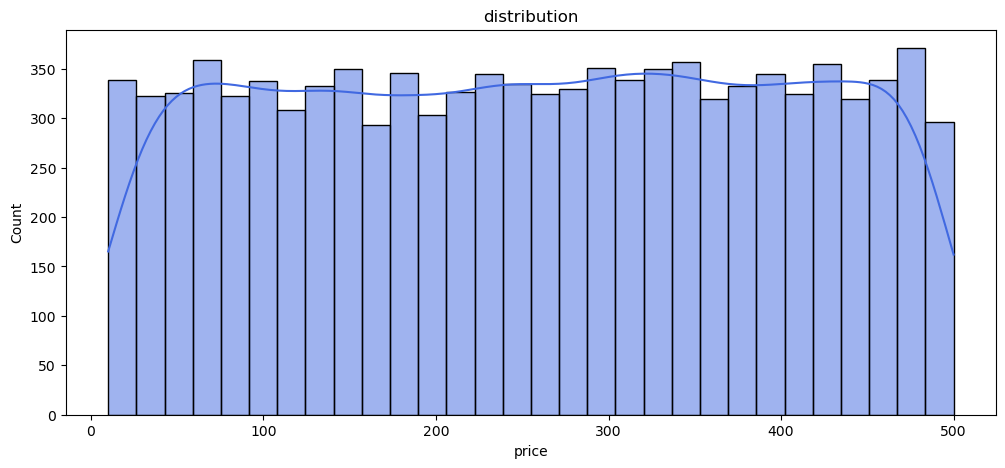


Total Sum is: 2559739.73


In [ ]:
# "Price" distribution

ua.dist("price","distribution")

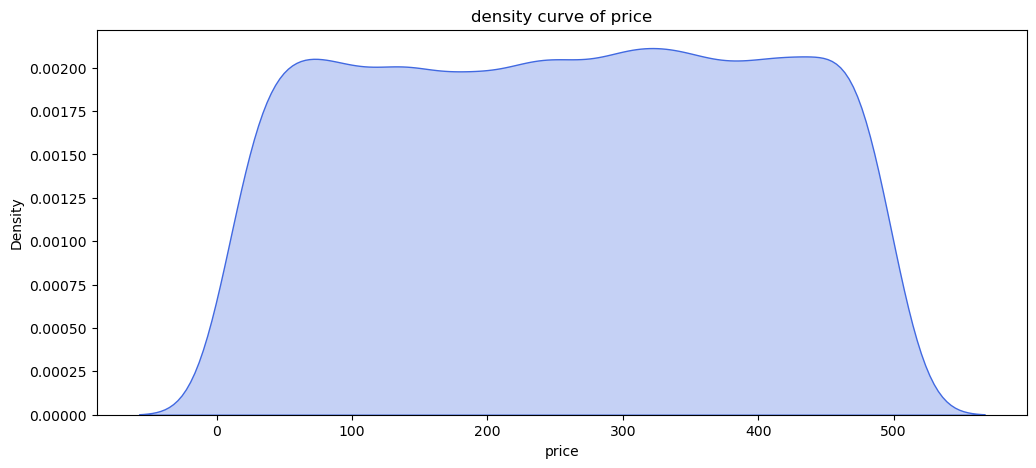

In [ ]:
# "Price" density curve

ua.kde("price","density curve of")

d:\Documents\github\Retail_Shelf_Space_Optimizer\retail_shelf_space_optimizer\EDA\univariate_analysis.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  total = self.df.groupby(col1)[col2].nunique()
d:\Documents\github\Retail_Shelf_Space_Optimizer\retail_shelf_space_optimizer\EDA\univariate_analysis.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  total = self.df.groupby(col1)[col2].count()


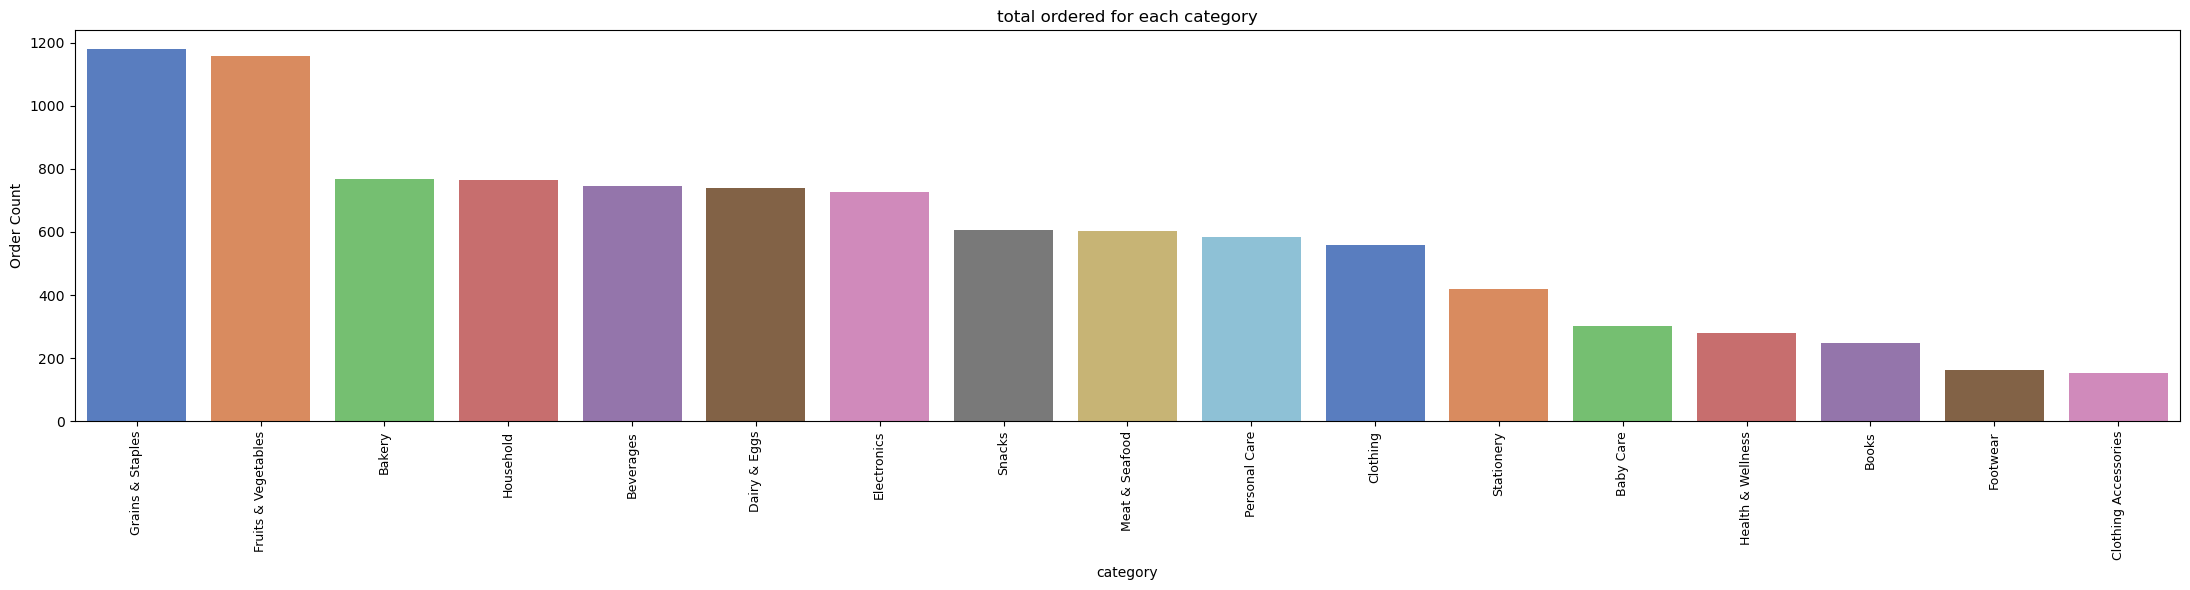

In [ ]:
# total ordered from each category?

ua.bar("category","product_id","total ordered for each category")

In [ ]:
# total number of quantity sold/ordered?


print(df['user_id'].nunique())
ua.col_quantity("quantity")

488
total number of customer: 3


count    10000.000000
mean         2.009400
std          0.820597
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: quantity, dtype: float64

d:\Documents\github\Retail_Shelf_Space_Optimizer\retail_shelf_space_optimizer\EDA\univariate_analysis.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



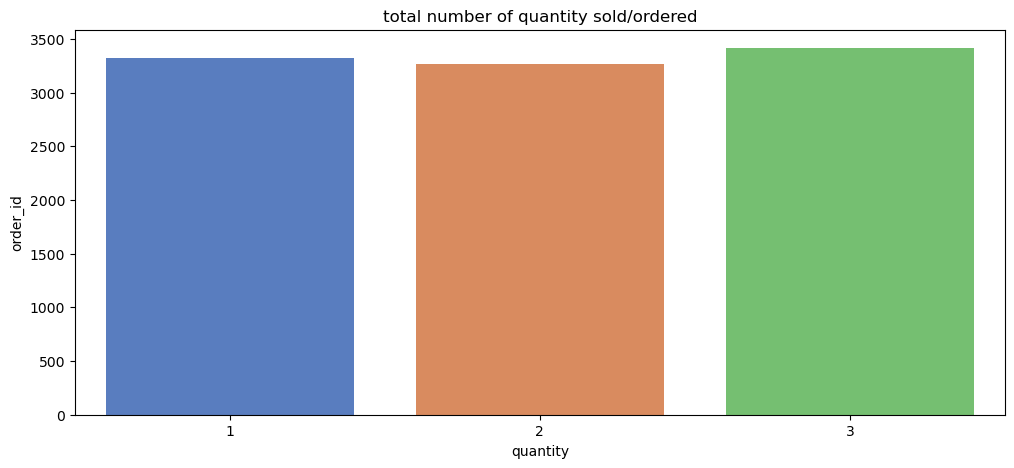

,quantity,order_id
2,3,3414
0,1,3320
1,2,3266


In [195]:
# total number of quantity sold/ordered

ua.normal_bar("quantity","order_id","total number of quantity sold/ordered")

***conclusion***

**Year Trend Analysis**

January (Month 1) is the peak ordered month with 185 orders. August (Month 8) also recorded 183 orders. Therefore, both January and August are considered the peak ordered months.
Hour Trend
6 AM to 8 AM and 2 PM to 4 PM have good order volumes. The peak hour is 11 AM. Morning gym customers, night workers, and afternoon children and housewives are buying products/items.
Top Most Ordered Products


**The total number of products is 68. The top most ordered products are:**

Chips
Energy Drink
Dishwashing Liquid
Cake
Tissue
Soda
Shoes
Prawns
Phone Cover
Face Wash

These products have **160+** orders and are among the most frequently ordered products.

**Price Distribution**

The total revenue is 2,559,739.73. There is no significant customer level identified. Customers are distributed across all price levels.

**Overall Category Trend**

Grains & Staples and Fruits & Vegetables are the most ordered categories.

**Quantity Sold**

There are three quantity levels: 1, 2, and 3. All quantity levels are ordered, and there is no significant gap between them.

**Bivariate Analysis**

In [2]:
data = "data/retail_data_interim.csv"

In [3]:
df = pd.read_csv(data)

In [ ]:
from steps.bivariate_analysis import Bivariate_Analysis
from steps import bivariate_analysis

importlib.reload(bivariate_analysis)

ba = Bivariate_Analysis(df)

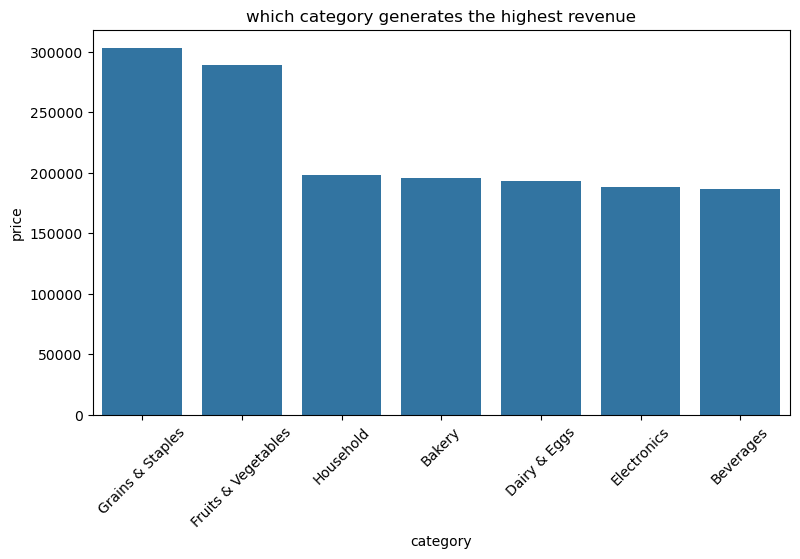

,category,price
0,Grains & Staples,302896.38
1,Fruits & Vegetables,289229.32
2,Household,198315.96
3,Bakery,195762.40
4,Dairy & Eggs,193506.58


In [18]:
# which category generates the highest revenue?

ba.bar_for_revenue("category","price","which category generates the highest revenue")

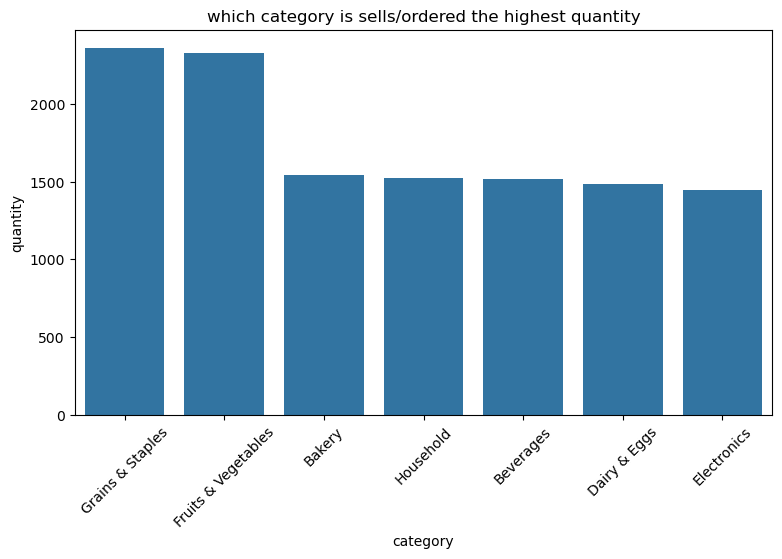

,category,quantity
0,Grains & Staples,2359
1,Fruits & Vegetables,2326
2,Bakery,1545
3,Household,1523
4,Beverages,1519


In [19]:
# which category is sells/ordered the highest quantity

ba.bar_for_revenue("category","quantity","which category is sells/ordered the highest quantity")

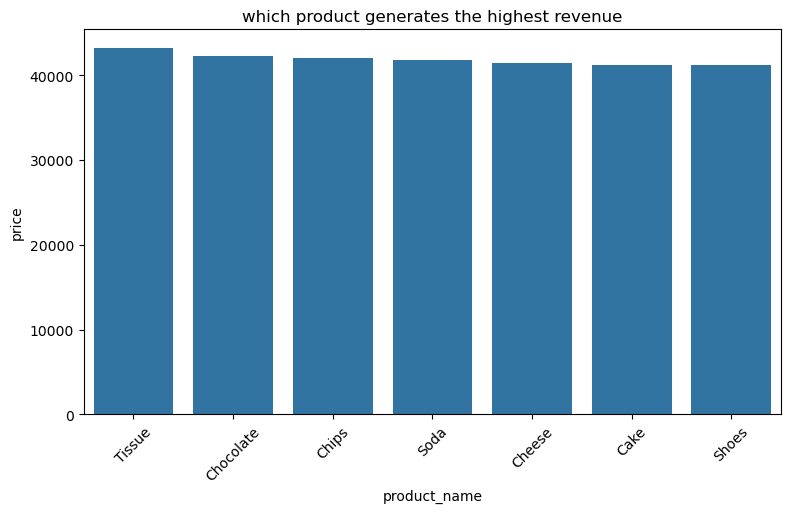

,product_name,price
0,Tissue,43230.81
1,Chocolate,42249.21
2,Chips,42005.26
3,Soda,41781.76
4,Cheese,41469.54


In [20]:
# which product generates the highest revenue?

ba.bar_for_revenue("product_name","price","which product generates the highest revenue")

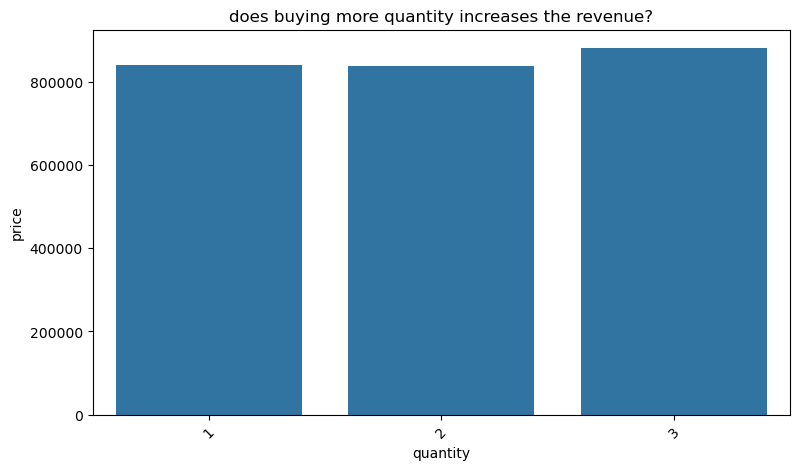

,quantity,price
0,3,881495.40
1,1,840868.50
2,2,837375.83


In [22]:
ba.bar_for_revenue("quantity","price","does buying more quantity increases the revenue?")

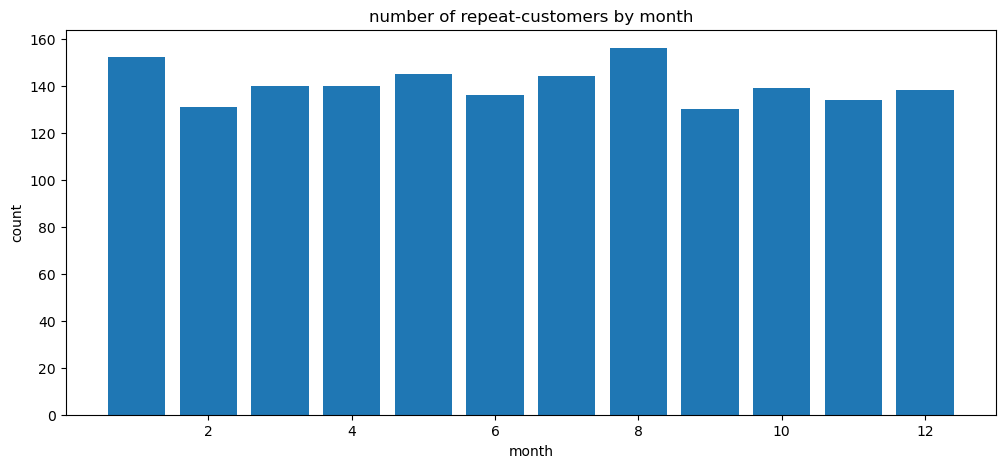

month
8     156
1     152
5     145
7     144
3     140
4     140
10    139
12    138
6     136
11    134
2     131
9     130
Name: user_id, dtype: int64

In [131]:
ba.find_repeat_customers()

Multivariate Analysis

In [ ]:
from steps import multivariate_analysis
from steps.multivariate_analysis import Multivariate_Analysis
importlib.reload(multivariate_analysis)

ma = Multivariate_Analysis(df)

In [ ]:
# which category generates the highest revenue in each month

ma.multi_for_revenue_unstack("month","category","price")

category,Baby Care,Bakery,Beverages,Books,Clothing,Clothing Accessories,Dairy & Eggs,Electronics,Footwear,Fruits & Vegetables,Grains & Staples,Health & Wellness,Household,Meat & Seafood,Personal Care,Snacks,Stationery
month,,,,,,,,,,,,,,,,,
1,7087.71,17209.73,12562.91,5661.68,15178.48,3645.66,18302.46,18845.61,4945.89,27089.51,25107.84,6244.61,23754.29,12751.69,13565.05,16346.97,10734.00
2,3944.25,15763.74,16032.77,5880.00,16281.60,5280.37,18373.20,12238.06,2091.69,26708.01,24031.49,4910.71,14884.72,16541.06,12104.63,10569.89,10885.62
3,4312.33,14755.19,15794.01,6016.25,11313.66,4877.98,15637.32,15852.71,3401.77,22928.17,27415.43,5205.78,15180.21,11938.67,11445.37,14811.56,8845.13
4,5941.87,17022.28,15442.08,7051.83,9614.23,3416.44,14030.73,13918.10,795.53,20433.12,20362.99,7221.15,14512.57,12874.46,11465.79,15301.92,3874.56
5,7064.83,20698.87,11588.23,3315.42,10881.58,3534.86,11487.10,13757.22,1574.49,21041.42,28794.10,8116.06,16820.87,17774.85,13393.26,11364.36,8313.83
6,4230.08,18564.66,18436.57,5349.73,6847.23,2639.34,16518.73,16165.71,3580.86,26512.60,24188.52,6193.70,14043.65,11134.94,10248.23,14316.73,8645.05
7,7680.74,18449.71,18027.23,7869.78,10554.49,2754.07,12871.21,18532.74,4329.14,26130.47,22168.44,6841.85,13971.13,12173.73,14679.65,12932.11,7254.24
8,7628.06,18608.41,15199.90,4606.08,10686.88,3289.50,20985.48,16390.27,3345.92,27899.13,32162.59,3703.96,22279.83,14038.79,12776.38,11339.21,12239.96
9,9338.70,10964.28,14591.54,4986.56,9778.96,3135.58,16023.50,14420.43,3142.65,20934.73,24874.32,5739.53,17481.61,14753.88,10042.68,11592.87,8161.17


In [107]:
# finding the highest orders hour by each category

ma.multi_for_count("hour","category","order_id")

category,Baby Care,Bakery,Beverages,Books,Clothing,Clothing Accessories,Dairy & Eggs,Electronics,Footwear,Fruits & Vegetables,Grains & Staples,Health & Wellness,Household,Meat & Seafood,Personal Care,Snacks,Stationery
hour,,,,,,,,,,,,,,,,,
6,15,46,44,20,35,13,52,43,13,78,71,14,53,43,31,34,36
7,18,41,56,18,47,15,42,44,12,90,91,27,43,33,50,29,14
8,16,33,48,18,37,6,48,36,9,74,80,26,59,42,41,37,25
9,23,56,43,17,34,6,34,40,12,56,69,20,38,32,41,31,19
10,20,46,35,13,32,10,37,40,5,61,60,21,34,35,37,29,22
11,14,60,50,12,41,9,49,42,11,73,84,16,58,46,34,33,23
12,17,37,46,15,40,10,42,35,10,63,59,20,52,28,38,36,31
13,10,39,37,10,29,6,38,43,9,75,63,18,49,37,39,34,21
14,19,45,38,13,27,9,41,41,5,69,59,13,43,39,33,33,24


In [108]:
# which hour are buiset in each month?

ma.multi_for_count("month","hour","order_id")

hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
month,,,,,,,,,,,,,,,,,
1,46,37,86,47,74,43,57,59,65,73,46,55,55,45,35,58,60
2,68,43,68,55,52,95,50,43,33,46,42,28,52,21,52,51,26
3,57,26,41,57,17,42,38,66,18,57,59,53,52,70,55,77,38
4,70,71,40,17,35,48,43,45,58,23,62,31,40,39,26,39,71
5,35,62,32,73,26,79,40,55,47,72,41,59,31,43,37,62,34
6,52,45,82,30,44,55,31,55,31,58,72,20,26,34,67,73,16
7,69,69,50,60,41,19,35,30,54,57,35,49,46,50,61,57,72
8,66,42,52,61,82,42,72,57,79,39,77,30,61,80,48,22,31
9,43,55,65,50,55,31,37,30,43,55,50,39,46,27,51,22,63


In [ ]:
# which producs is generated highest revenue by each category?

ma.multi_for_revenue("category","product_name","price")

category           product_name    
Household          Tissue              43230.81
Snacks             Chocolate           42249.21
                   Chips               42005.26
Beverages          Soda                41781.76
Dairy & Eggs       Cheese              41469.54
                                         ...   
Beverages          Juice               33563.66
Books              Educational Book    31678.32
Health & Wellness  Vitamins            31009.56
Stationery         Marker              29823.79
Clothing           Shirt               29733.18
Name: price, Length: 68, dtype: float64